# Visualize 2–3 sample trajectories per behavior mode

Loads dataset npz (scp, cvx, param), picks 2–3 samples per behavior mode (0..26), and plots them on the same canvas as `test_data_generation.ipynb`: table + obstacles (`_plot_environment`) and the 3×3 spatial grid (x > 1.2).

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# Repo root (parent of freeflyer/)
root_folder = Path.cwd().parent
sys.path.append(str(root_folder))

import optimization.ff_scenario as ff
from optimization.ff_scenario import obs, robot_radius, table

In [3]:
def _plot_environment(ax):
    """Table + obstacles (reference from test_data_generation.ipynb)."""
    # Table
    ax.add_patch(
        Rectangle(
            (table["xy_low"][0], table["xy_low"][1]),
            table["xy_up"][0] - table["xy_low"][0],
            table["xy_up"][1] - table["xy_low"][1],
            fc=(0.5, 0.5, 0.5, 0.15),
            ec="k",
            label="",
            zorder=2.5,
        )
    )
    # Obstacles + inflated robot radius
    for n in range(obs["radius"].shape[0]):
        lab1 = ""
        lab3 = "" if n == 0 else None
        lab2 = "" if n == 0 else None
        if n == 1:
            ax.add_patch(
                Circle(
                    obs["position"][n, :],
                    obs["radius"][n],
                    fc="r",
                    ec="none",
                    label=lab1,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs["position"][n, :],
                    obs["radius"][n] + robot_radius,
                    fc="grey",
                    alpha=0.2,
                    ec="none",
                    label=lab2,
                    zorder=2.6,
                )
            )
        else:
            ax.add_patch(
                Circle(
                    obs["position"][n, :],
                    obs["radius"][n],
                    fc="g",
                    ec="none",
                    label=lab3,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs["position"][n, :],
                    obs["radius"][n] + robot_radius,
                    fc="grey",
                    alpha=0.2,
                    ec="none",
                    label=lab2,
                    zorder=2.6,
                )
            )
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X, m")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(table["xy_low"][0], table["xy_up"][0])
    ax.set_ylim(table["xy_low"][1], table["xy_up"][1])

In [5]:
def build_goal_regions_3x3_xgt12(x_min=1.2, ncols=3, nrows=3):
    """3×3 grid for x > x_min. Returns (regions, xs, ys) as in test_data_generation."""
    table_lo = np.asarray(ff.table["xy_low"], dtype=float)
    table_hi = np.asarray(ff.table["xy_up"], dtype=float)
    xlo = max(float(x_min), float(table_lo[0]))
    xhi = float(table_hi[0])
    ylo = float(table_lo[1])
    yhi = float(table_hi[1])
    xs = np.linspace(xlo, xhi, ncols + 1)
    ys = np.linspace(ylo, yhi, nrows + 1)
    regions = []
    for r in range(nrows):
        for c in range(ncols):
            regions.append((xs[c], xs[c + 1], ys[r], ys[r + 1]))
    return regions, xs, ys


def plot_9_region_grid(ax, x_min=1.2, xs=None, ys=None, annotate=False):
    """Draw 3×3 grid lines on x > x_min (spatial discretization for behavior_mode)."""
    if xs is None or ys is None:
        _, xs, ys = build_goal_regions_3x3_xgt12(x_min=x_min)
    x0, x1 = xs[0], xs[-1]
    y0, y1 = ys[0], ys[-1]
    for x in xs:
        ax.plot([x, x], [y0, y1], color="k", linewidth=0.8, alpha=0.6)
    for y in ys:
        ax.plot([x0, x1], [y, y], color="k", linewidth=0.8, alpha=0.6)
    if annotate:
        rid = 0
        for r in range(len(ys) - 1):
            for c in range(len(xs) - 1):
                cx = 0.5 * (xs[c] + xs[c + 1])
                cy = 0.5 * (ys[r] + ys[r + 1])
                ax.text(cx, cy, str(rid), ha="center", va="center", fontsize=7)
                rid += 1

In [ ]:
dataset_version = "v02"
scp_path = root_folder / "dataset" / f"dataset-ff-{dataset_version}-scp.npz"
cvx_path = root_folder / "dataset" / f"dataset-ff-{dataset_version}-cvx.npz"
param_path = root_folder / "dataset" / f"dataset-ff-{dataset_version}-param.npz"

scp = np.load(scp_path, allow_pickle=True)
cvx = np.load(cvx_path, allow_pickle=True)
par = np.load(param_path, allow_pickle=True)

states_scp = scp["states_scp"]
states_cvx = cvx["states_cvx"]
behavior_mode = par["behavior_mode"]
region_id = par["region_id"]
time_id = par["time_id"]
k_T = par["k_T"]
goal_xy = par["goal_xy"]

regions, grid_xs, grid_ys = build_goal_regions_3x3_xgt12(x_min=1.2, ncols=3, nrows=3)
n_modes = 27  # 9 regions × 3 time horizons
samples_per_mode = 3  # 2–3 trajectories per behavior mode

# For each behavior mode, pick up to samples_per_mode random indices
# (only from samples with k_T > 0 so trajectories are non-empty)
rng = np.random.default_rng(42)
indices_per_bm = []
for bm in range(n_modes):
    idxs = np.where(behavior_mode == bm)[0]
    idxs_valid = idxs[k_T[idxs] > 0]  # skip samples with empty trajectory
    n_pick = min(samples_per_mode, len(idxs_valid))
    if n_pick > 0:
        indices_per_bm.append(rng.choice(idxs_valid, size=n_pick, replace=False).tolist())
    else:
        indices_per_bm.append([])

print("Loaded:", states_scp.shape, "| behavior_mode unique:", len(np.unique(behavior_mode)))
print("Samples per mode (first 5):", [len(indices_per_bm[bm]) for bm in range(5)])
# Diagnostic: for bm=0, how many have k_T>0 vs total?
bm0_idxs = np.where(behavior_mode == 0)[0]
bm0_valid = np.sum(k_T[bm0_idxs] > 0)
print(f"bm=0: {bm0_valid} with k_T>0 (plottable) out of {len(bm0_idxs)} total")

Loaded: (600000, 100, 6) | behavior_mode unique: 27
Samples per mode (first 5): [3, 3, 3, 3, 3]
bm=0: 18940 with k_T>0 (plottable) out of 139459 total


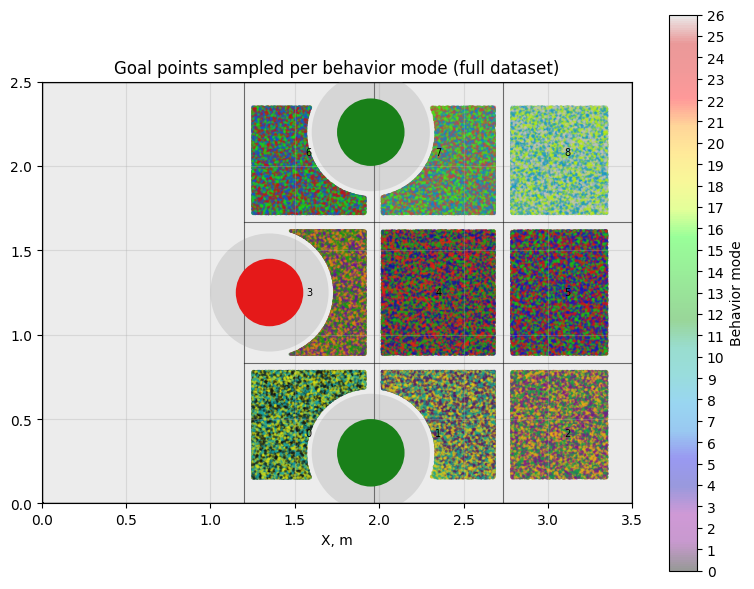

In [7]:
# Scatter: all goal points in the dataset, colored by behavior mode (0..26)
fig, ax = plt.subplots(figsize=(8, 6))
_plot_environment(ax)
plot_9_region_grid(ax, x_min=1.2, xs=grid_xs, ys=grid_ys, annotate=True)

sc = ax.scatter(
    goal_xy[:, 0],
    goal_xy[:, 1],
    c=behavior_mode,
    s=1.5,
    alpha=0.4,
    cmap="nipy_spectral",
    vmin=0,
    vmax=26,
)
cbar = plt.colorbar(sc, ax=ax, label="Behavior mode")
cbar.set_ticks(np.arange(27))
ax.set_title("Goal points sampled per behavior mode (full dataset)")
plt.tight_layout()
plt.show()

**Grid:** 9 rows = region_id 0..8 (3×3 spatial grid for x > 1.2), 3 columns = time_id 0,1,2 (k_T = 60, 80, 100). Each panel shows 2–3 SCP trajectories for that behavior mode; start (circle) and goal (x) shown for the first trajectory.

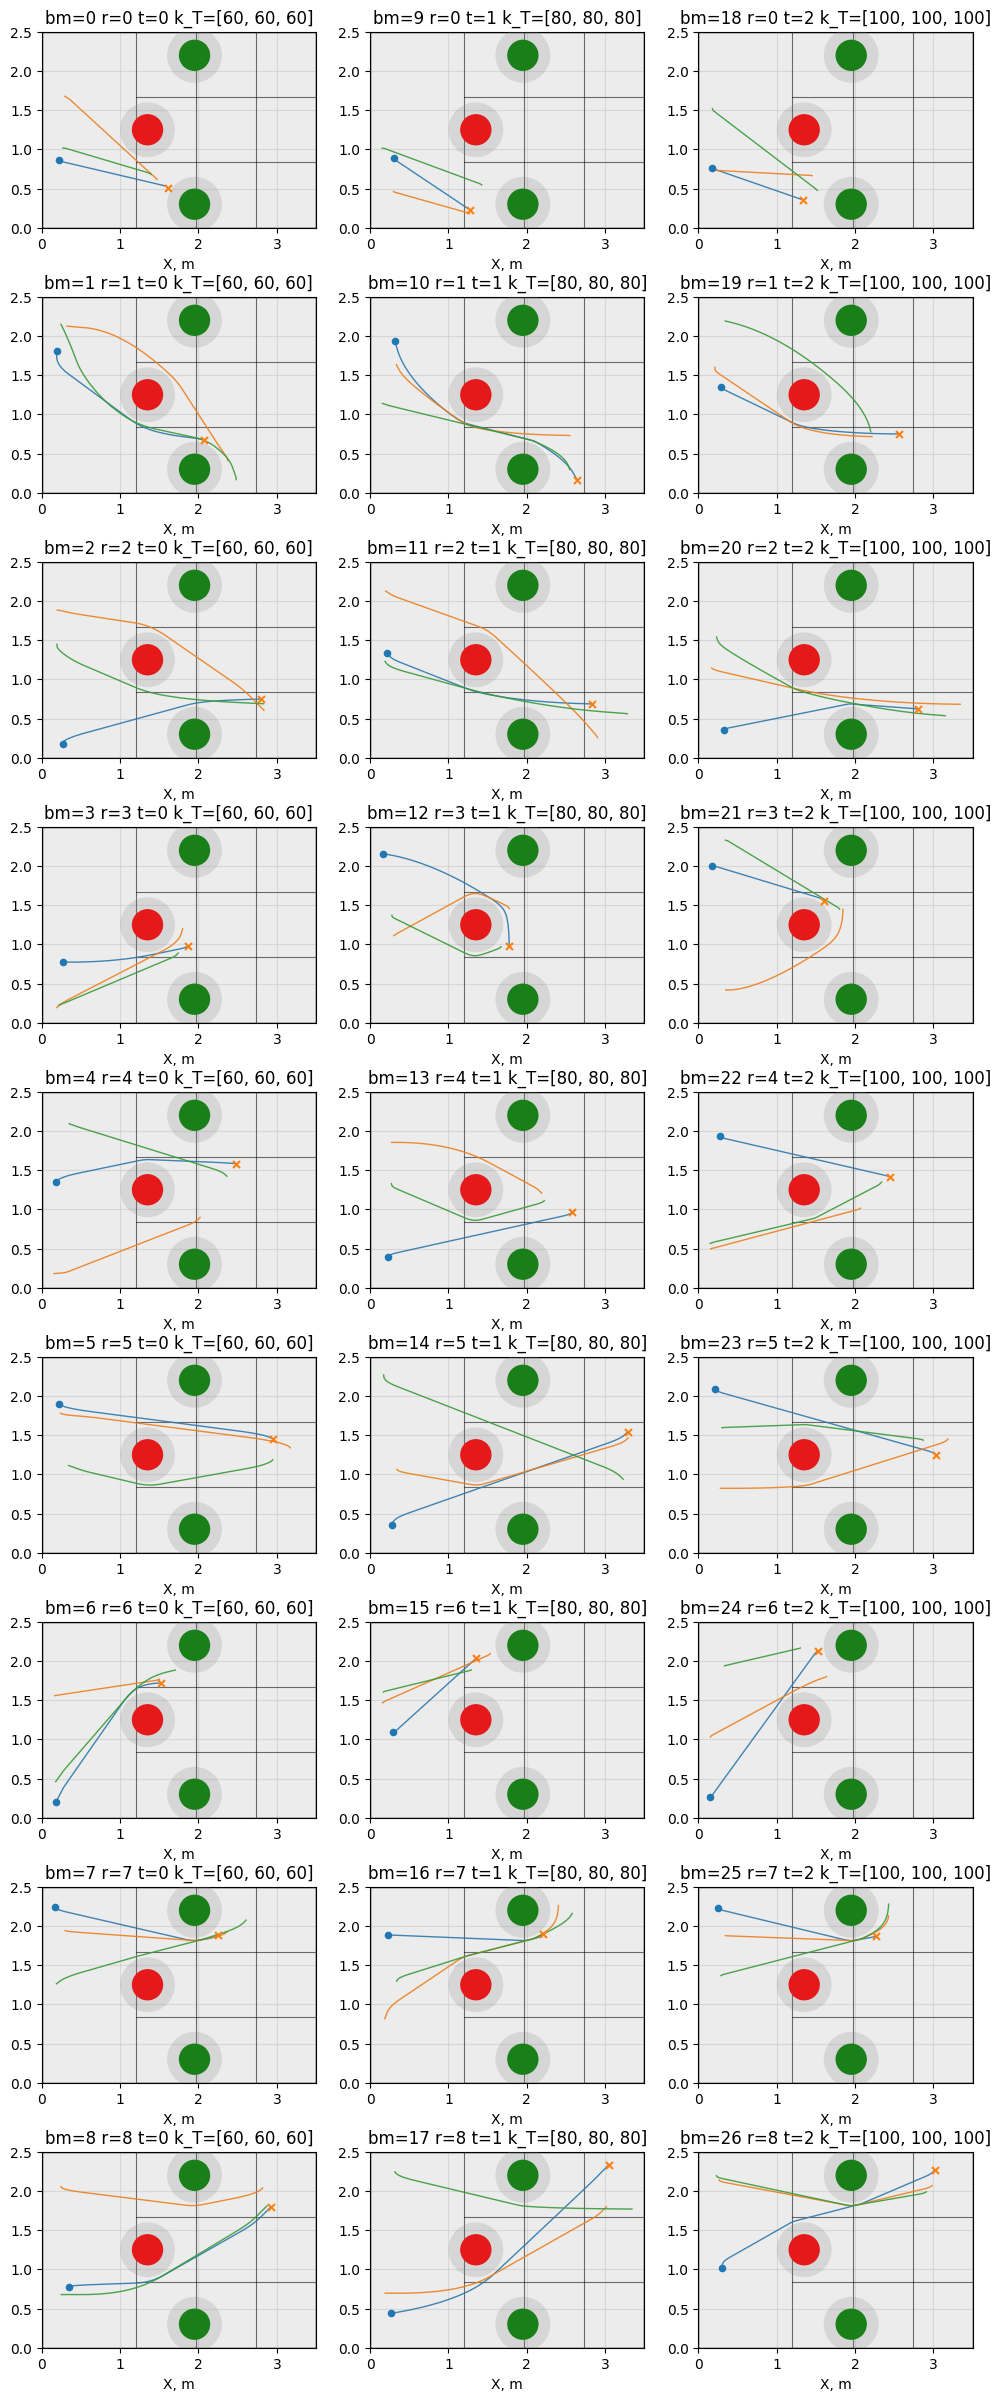

In [8]:
# One figure: 9 rows (region_id 0..8) × 3 cols (time_id 0,1,2) → behavior_mode = 9*time_id + region_id
fig, axs = plt.subplots(9, 3, figsize=(10, 24))
for bm in range(n_modes):
    r, c = bm % 9, bm // 9
    ax = axs[r, c]
    _plot_environment(ax)
    plot_9_region_grid(ax, x_min=1.2, xs=grid_xs, ys=grid_ys, annotate=False)
    idxs = indices_per_bm[bm]
    for i, idx in enumerate(idxs):
        kk = int(k_T[idx])
        if kk <= 0:
            continue
        xy = states_scp[idx, :kk, 0:2]
        ax.plot(xy[:, 0], xy[:, 1], linewidth=1.0, alpha=0.9)
        if i == 0:
            ax.scatter(xy[0, 0], xy[0, 1], s=20, marker="o", color="C0", zorder=5)
            g = goal_xy[idx]
            ax.scatter(g[0], g[1], s=25, marker="x", color="C1", zorder=5)
    k_T_vals = [int(k_T[idx]) for idx in idxs] if idxs else []
    ax.set_title(f"bm={bm} r={bm%9} t={bm//9} k_T={k_T_vals}")
plt.tight_layout()
plt.show()

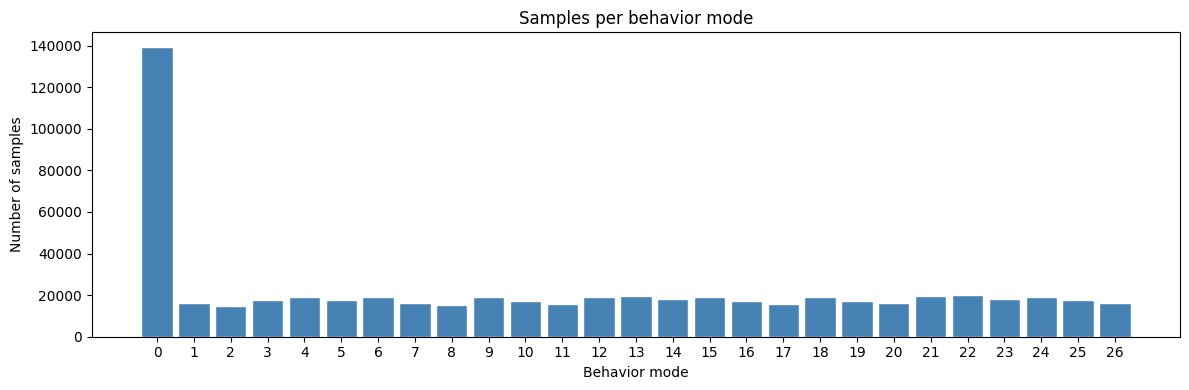

In [8]:
# Histogram: number of samples per behavior mode (0..26)
fig, ax = plt.subplots(figsize=(12, 4))
counts, bins, _ = ax.hist(behavior_mode, bins=np.arange(28) - 0.5, rwidth=0.85, color="steelblue", edgecolor="white")
ax.set_xlabel("Behavior mode")
ax.set_ylabel("Number of samples")
ax.set_title("Samples per behavior mode")
ax.set_xticks(np.arange(27))
ax.set_xticklabels([f"{i}" for i in range(27)])
plt.tight_layout()
plt.show()


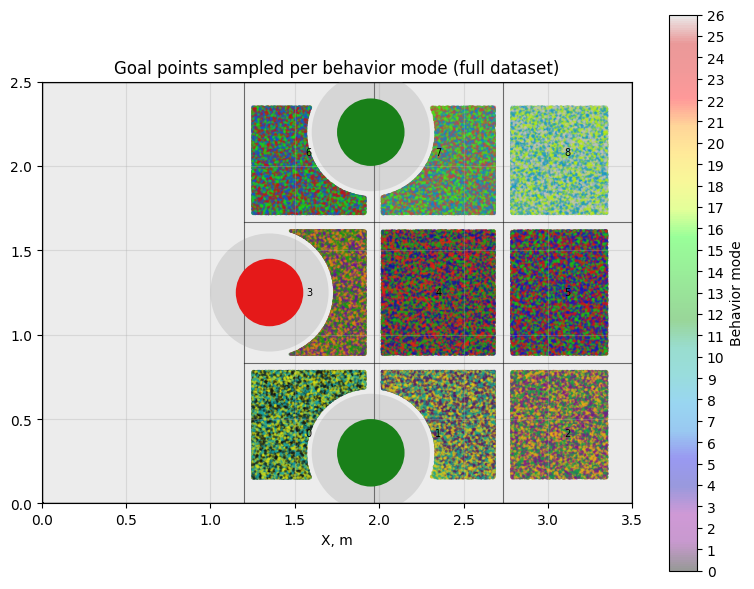

In [9]:
# Scatter: all goal points in the dataset, colored by behavior mode (0..26)
fig, ax = plt.subplots(figsize=(8, 6))
_plot_environment(ax)
plot_9_region_grid(ax, x_min=1.2, xs=grid_xs, ys=grid_ys, annotate=True)

sc = ax.scatter(
    goal_xy[:, 0],
    goal_xy[:, 1],
    c=behavior_mode,
    s=1.5,
    alpha=0.4,
    cmap="nipy_spectral",
    vmin=0,
    vmax=26,
)
cbar = plt.colorbar(sc, ax=ax, label="Behavior mode")
cbar.set_ticks(np.arange(27))
ax.set_title("Goal points sampled per behavior mode (full dataset)")
plt.tight_layout()
plt.show()